# 1、添加步骤

正常对话，为图添加步骤。每个步骤都将在其状态历史中被检查点化

In [1]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool, InjectedToolCallId
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

# 加载 .env 文件
load_dotenv(override=True)


os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "langgraph_learnning"
os.environ["LANGSMITH_ENDPOINT"] = "https://aws.api.smith.langchain.com"

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
llm = ChatOpenAI(
    model="mimo-v2-pro",
    base_url=os.getenv("XIAOMI_BASE_URL"),
    api_key=os.getenv("XIAOMI_API_KEY"))

tavily_search_tool = TavilySearch(max_results=2, api_key=os.getenv("TAVILY_API_KEY"))

tools = [tavily_search_tool]

llm_with_tool = llm.bind_tools(tools)

In [4]:
def chat_model(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

graph_builder.add_node("chat_model", chat_model)

tool_node = ToolNode(tools)

graph_builder.add_node("tools", tool_node)

graph_builder.add_edge("tools", "chat_model")
graph_builder.add_edge(START, "chat_model")
graph_builder.add_conditional_edges("chat_model", tools_condition)

graph = graph_builder.compile(checkpointer=memory)

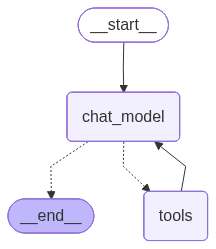

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [6]:
config = {"configurable": {"thread_id": "1"}}

while True:
    user_input = input()

    if user_input.lower() in ("exit", "quit", "q"):
        print("bye")
        break
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]},
                             config,
                             stream_mode="values"):
        event["messages"][-1].pretty_print()

 你好，我是yang，你叫什么名字


================================ Human Message =================================

你好，我是yang，你叫什么名字
================================== Ai Message ==================================

你好，Yang！很高兴认识你 😊

我叫**MiMo-v2-pro**，是由**小米MiMo团队**开发的AI助手。我有1万亿参数和100万token的上下文窗口，希望能为你提供有用的帮助！

有什么我可以为你做的吗？


 搜索一下deepssek最新的模型名称是什么


================================ Human Message =================================

搜索一下deepssek最新的模型名称是什么
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_8f48c32e95c04a729c29d857)
 Call ID: call_8f48c32e95c04a729c29d857
  Args:
    query: DeepSeek 最新模型 名称 2024
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "DeepSeek 最新模型 名称 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://fishersama.com/deepseek-timeline", "title": "DeepSeek 时间线与模型发布速览 - AI 工具箱", "content": "DeepSeek-Coder-V2 基于DeepSeekMoE 框架，提供16B 和236B 总参数量的模型，并提供Base 和Instruct 模型，MIT 许可均可公开下载和商用。 2024年5月. 开源DeepSeek-V2 系列模型.", "score": 0.9998191, "raw_content": null}, {"url": "https://udn.com/news/story/7333/9263691", "title": "DeepSeek下一代AI模型來了旗艦版V4傳2月亮相 - 聯合新聞網", "content": "自2024年底發布V3模型後，DeepSeek的下一代旗艦模型一直未出，科技媒體The Information近期引述

 你还记得我是谁吗


================================ Human Message =================================

你还记得我是谁吗
================================== Ai Message ==================================

当然记得！你是**Yang**，对吧？我们刚刚聊过天，你还让我搜索了DeepSeek最新模型的信息。

刚才我帮你查到了DeepSeek最新的**V4系列模型**，包括V4-Pro和V4-Flash两个版本。

还有什么我可以继续帮你的吗？😊


 exit


bye


# 2、重播完整状态历史

现在你已经为聊天机器人添加了步骤，你可以重播完整状态历史以查看发生的一切

In [7]:
_replay = None
for _state in graph.get_state_history(config):
    print("Message number:", len(_state.values["messages"]), "Next:",  _state.next)
    # 这里是随意设置了一个条件，将state回溯到了历史记录为10条的状态
    if len(_state.values["messages"]) == 12:
        _replay = _state

Message number: 14 Next ()
Message number: 13 Next ('chat_model',)
Message number: 12 Next ('__start__',)
Message number: 12 Next ()
Message number: 11 Next ('chat_model',)
Message number: 10 Next ('tools',)
Message number: 9 Next ('chat_model',)
Message number: 8 Next ('tools',)
Message number: 7 Next ('chat_model',)
Message number: 6 Next ('tools',)
Message number: 5 Next ('chat_model',)
Message number: 4 Next ('tools',)
Message number: 3 Next ('chat_model',)
Message number: 2 Next ('__start__',)
Message number: 2 Next ()
Message number: 1 Next ('chat_model',)
Message number: 0 Next ('__start__',)


# 3、从检查点加载状态

检查点的_replay.config包含一个checkpoint_id时间戳。提供此checkpoint_id值会告诉LangGraph的检查器加载该时间点的状态。

In [8]:
for event in graph.stream(None, _replay.config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_73ce9a238da04d06b57c306d)
 Call ID: call_73ce9a238da04d06b57c306d
  Args:
    query: DeepSeek latest model 2025 V4 release
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "DeepSeek latest model 2025 V4 release", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/deepseek-releases-v4-extends-open-source-ai-reach-119709dd", "title": "DeepSeek Releases V4, Extends Open-Source AI Reach | Let's Data Science", "content": "DeepSeek released a preview of V4 on April 24, publishing open weights and API details for two variants, per DeepSeek's API release notes and documentation. According to DeepSeek's API page, deepseek-v4-pro is a Mixture-of-Experts model with 1.6T total and 49B active parameters, and deepsee

In [9]:
while True:
    user_input = input()

    if user_input.lower() in ("exit", "quit", "q"):
        print("bye")
        break
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]},
                             config,
                             stream_mode="values"):
        event["messages"][-1].pretty_print()

 咱们上一步做的是什么


================================ Human Message =================================

咱们上一步做的是什么
================================== Ai Message ==================================

我们上一步做的是：**搜索 DeepSeek 最新的模型名称**。

具体过程是：
1. 您询问 DeepSeek 最新的模型名称是什么
2. 我通过多次网络搜索，查询了 DeepSeek 在 2025-2026 年间的模型发布情况
3. 最终整理出最新信息：**DeepSeek-V4 Preview**（2026年4月24日发布）是目前最新的模型版本
4. 同时我也列出了近期发布的其他重要版本，如 DeepSeek-V3.2（2025年12月）、DeepSeek-R1（2025年1月）等

您还想了解关于 DeepSeek 模型的其他信息吗？比如具体性能对比、使用场景或者 API 接入方式等？


 exit


bye


In [10]:
for _state in graph.get_state_history(config):
    print("Message number:", len(_state.values["messages"]), "Next:",  _state.next)

Message number: 28 Next ()
Message number: 27 Next ('chat_model',)
Message number: 26 Next ('__start__',)
Message number: 26 Next ()
Message number: 25 Next ('chat_model',)
Message number: 24 Next ('tools',)
Message number: 23 Next ('chat_model',)
Message number: 22 Next ('tools',)
Message number: 21 Next ('chat_model',)
Message number: 20 Next ('tools',)
Message number: 19 Next ('chat_model',)
Message number: 18 Next ('tools',)
Message number: 17 Next ('chat_model',)
Message number: 16 Next ('tools',)
Message number: 15 Next ('chat_model',)
Message number: 14 Next ('tools',)
Message number: 13 Next ('chat_model',)
Message number: 12 Next ('tools',)
Message number: 11 Next ('chat_model',)
Message number: 10 Next ('tools',)
Message number: 14 Next ()
Message number: 13 Next ('chat_model',)
Message number: 12 Next ('__start__',)
Message number: 12 Next ()
Message number: 11 Next ('chat_model',)
Message number: 10 Next ('tools',)
Message number: 9 Next ('chat_model',)
Message number: 8 Ne